In [5]:
import pandas as pd
df = pd.read_csv("D:\ML PROJECTS\AML lab\dataset\HistoricalQuotes.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2518 entries, 0 to 2517
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         2518 non-null   object
 1    Close/Last  2518 non-null   object
 2    Volume      2518 non-null   int64 
 3    Open        2518 non-null   object
 4    High        2518 non-null   object
 5    Low         2518 non-null   object
dtypes: int64(1), object(5)
memory usage: 118.2+ KB


In [11]:
import pandas as pd
import numpy as np
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

class StockAdaBoostAnalyzer:
    def __init__(self):
        self.scaler = StandardScaler()
        self.model = None
        self.feature_names = None
        
    def load_and_preprocess_data(self, df):
        """
        Load and preprocess the stock data
        """
        # Create a copy of the dataframe
        data = df.copy()
        
        # Convert Date to datetime if it's not already
        if data['Date'].dtype == 'object':
            data['Date'] = pd.to_datetime(data['Date'])
        
        # Clean price columns (remove $ and convert to float)
        price_columns = [' Close/Last', ' Open', ' High', ' Low']
        for col in price_columns:
            if col in data.columns:
                if data[col].dtype == 'object':
                    data[col] = data[col].str.replace('$', '').astype(float)
        
        # Sort by date
        data = data.sort_values('Date').reset_index(drop=True)
        
        return data
    
    def engineer_features(self, data):
        """
        Create technical indicators and features for AdaBoost
        """
        df = data.copy()
        
        # Basic price features
        df['Price_Range'] = df[' High'] - df[' Low']
        df['Price_Change'] = df[' Close/Last'] - df[' Open']
        df['Price_Change_Pct'] = (df[' Close/Last'] - df[' Open']) / df[' Open'] * 100
        
        # Moving averages
        df['MA_5'] = df[' Close/Last'].rolling(window=5).mean()
        df['MA_10'] = df[' Close/Last'].rolling(window=10).mean()
        df['MA_20'] = df[' Close/Last'].rolling(window=20).mean()
        
        # Price relative to moving averages
        df['Price_vs_MA5'] = df[' Close/Last'] / df['MA_5']
        df['Price_vs_MA10'] = df[' Close/Last'] / df['MA_10']
        df['Price_vs_MA20'] = df[' Close/Last'] / df['MA_20']
        
        # Volatility measures
        df['Volatility_5'] = df[' Close/Last'].rolling(window=5).std()
        df['Volatility_10'] = df[' Close/Last'].rolling(window=10).std()
        
        # Volume features
        df['Volume_MA_5'] = df[' Volume'].rolling(window=5).mean()
        df['Volume_Ratio'] = df[' Volume'] / df['Volume_MA_5']
        
        # RSI (Relative Strength Index)
        delta = df[' Close/Last'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / loss
        df['RSI'] = 100 - (100 / (1 + rs))
        
        # MACD
        exp1 = df[' Close/Last'].ewm(span=12).mean()
        exp2 = df[' Close/Last'].ewm(span=26).mean()
        df['MACD'] = exp1 - exp2
        df['MACD_Signal'] = df['MACD'].ewm(span=9).mean()
        df['MACD_Histogram'] = df['MACD'] - df['MACD_Signal']
        
        # Bollinger Bands
        df['BB_Middle'] = df[' Close/Last'].rolling(window=20).mean()
        bb_std = df[' Close/Last'].rolling(window=20).std()
        df['BB_Upper'] = df['BB_Middle'] + (bb_std * 2)
        df['BB_Lower'] = df['BB_Middle'] - (bb_std * 2)
        df['BB_Position'] = (df[' Close/Last'] - df['BB_Lower']) / (df['BB_Upper'] - df['BB_Lower'])
        
        # Create target variable (next day price movement)
        df['Next_Close'] = df[' Close/Last'].shift(-1)
        df['Target'] = (df['Next_Close'] > df[' Close/Last']).astype(int)
        
        # Select features for modeling
        feature_columns = [
            'Price_Range', 'Price_Change', 'Price_Change_Pct',
            'Price_vs_MA5', 'Price_vs_MA10', 'Price_vs_MA20',
            'Volatility_5', 'Volatility_10', 'Volume_Ratio',
            'RSI', 'MACD', 'MACD_Signal', 'MACD_Histogram',
            'BB_Position'
        ]
        
        # Remove rows with NaN values
        df = df.dropna()
        
        return df, feature_columns
    
    def train_adaboost(self, X, y, test_size=0.2, random_state=42):
        """
        Train AdaBoost classifier with hyperparameter tuning
        """
        # Split the data
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=y
        )
        
        # Scale the features
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)
        
        # Hyperparameter tuning
        print("Performing hyperparameter tuning...")
        param_grid = {
            'n_estimators': [50, 100, 200],
            'learning_rate': [0.1, 0.5, 1.0, 1.5],
            'estimator__max_depth': [1, 2, 3]
        }
        
        estimator = DecisionTreeClassifier(random_state=random_state)
        ada_boost = AdaBoostClassifier(
            estimator= estimator,
            random_state=random_state,
            algorithm='SAMME'
        )
        
        grid_search = GridSearchCV(
            ada_boost, param_grid, cv=5, scoring='accuracy', n_jobs=-1
        )
        grid_search.fit(X_train_scaled, y_train)
        
        # Train the best model
        self.model = grid_search.best_estimator_
        print(f"Best parameters: {grid_search.best_params_}")
        print(f"Best cross-validation score: {grid_search.best_score_:.4f}")
        
        # Make predictions
        y_pred = self.model.predict(X_test_scaled)
        y_pred_proba = self.model.predict_proba(X_test_scaled)[:, 1]
        
        # Store results
        self.results = {
            'X_test': X_test_scaled,
            'y_test': y_test,
            'y_pred': y_pred,
            'y_pred_proba': y_pred_proba,
            'best_params': grid_search.best_params_,
            'feature_names': self.feature_names
        }
        
        return self.results
    
    def evaluate_model(self):
        """
        Evaluate the AdaBoost model performance
        """
        if self.results is None:
            print("Model not trained yet!")
            return
        
        y_test = self.results['y_test']
        y_pred = self.results['y_pred']
        y_pred_proba = self.results['y_pred_proba']
        
        # Basic metrics
        accuracy = accuracy_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_pred_proba)
        
        print("="*50)
        print("ADABOOST MODEL EVALUATION")
        print("="*50)
        print(f"Accuracy: {accuracy:.4f}")
        print(f"ROC AUC Score: {roc_auc:.4f}")
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        
        # Feature importance
        if hasattr(self.model, 'feature_importances_'):
            feature_importance = pd.DataFrame({
                'feature': self.feature_names,
                'importance': self.model.feature_importances_
            }).sort_values('importance', ascending=False)
            
            print("\nTop 10 Feature Importances:")
            print(feature_importance.head(10))
        
        return {
            'accuracy': accuracy,
            'roc_auc': roc_auc,
            'feature_importance': feature_importance
        }
    
    def plot_results(self):
        """
        Create visualizations for the AdaBoost results
        """
        if self.results is None:
            print("Model not trained yet!")
            return
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        
        # 1. Confusion Matrix
        cm = confusion_matrix(self.results['y_test'], self.results['y_pred'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0])
        axes[0,0].set_title('Confusion Matrix')
        axes[0,0].set_xlabel('Predicted')
        axes[0,0].set_ylabel('Actual')
        
        # 2. ROC Curve
        fpr, tpr, _ = roc_curve(self.results['y_test'], self.results['y_pred_proba'])
        roc_auc = roc_auc_score(self.results['y_test'], self.results['y_pred_proba'])
        axes[0,1].plot(fpr, tpr, color='darkorange', lw=2, 
                       label=f'ROC curve (AUC = {roc_auc:.2f})')
        axes[0,1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        axes[0,1].set_xlim([0.0, 1.0])
        axes[0,1].set_ylim([0.0, 1.05])
        axes[0,1].set_xlabel('False Positive Rate')
        axes[0,1].set_ylabel('True Positive Rate')
        axes[0,1].set_title('ROC Curve')
        axes[0,1].legend(loc="lower right")
        
        # 3. Feature Importance
        if hasattr(self.model, 'feature_importances_'):
            feature_importance = pd.DataFrame({
                'feature': self.feature_names,
                'importance': self.model.feature_importances_
            }).sort_values('importance', ascending=True).tail(10)
            
            axes[1,0].barh(range(len(feature_importance)), feature_importance['importance'])
            axes[1,0].set_yticks(range(len(feature_importance)))
            axes[1,0].set_yticklabels(feature_importance['feature'])
            axes[1,0].set_title('Top 10 Feature Importances')
            axes[1,0].set_xlabel('Importance')
        
        # 4. Prediction Distribution
        axes[1,1].hist(self.results['y_pred_proba'], bins=30, alpha=0.7, color='skyblue')
        axes[1,1].set_title('Prediction Probability Distribution')
        axes[1,1].set_xlabel('Predicted Probability')
        axes[1,1].set_ylabel('Frequency')
        
        plt.tight_layout()
        plt.show()
    
    def run_complete_analysis(self, df):
        """
        Run the complete AdaBoost analysis pipeline
        """
        print("Starting AdaBoost Analysis...")
        print("="*50)
        
        # 1. Preprocess data
        print("1. Preprocessing data...")
        data = self.load_and_preprocess_data(df)
        
        # 2. Engineer features
        print("2. Engineering features...")
        data_with_features, feature_columns = self.engineer_features(data)
        self.feature_names = feature_columns
        
        print(f"Created {len(feature_columns)} features")
        print(f"Dataset shape after preprocessing: {data_with_features.shape}")
        
        # 3. Prepare features and target
        X = data_with_features[feature_columns]
        y = data_with_features['Target']
        
        print(f"Target distribution:")
        print(y.value_counts(normalize=True))
        
        # 4. Train AdaBoost model
        print("\n3. Training AdaBoost model...")
        self.train_adaboost(X, y)
        
        # 5. Evaluate model
        print("\n4. Evaluating model...")
        evaluation_results = self.evaluate_model()
        
        # 6. Plot results
        print("\n5. Creating visualizations...")
        self.plot_results()
        
        return evaluation_results

Starting AdaBoost Analysis...
1. Preprocessing data...
2. Engineering features...
Created 14 features
Dataset shape after preprocessing: (2498, 29)
Target distribution:
Target
1    0.526421
0    0.473579
Name: proportion, dtype: float64

3. Training AdaBoost model...
Performing hyperparameter tuning...
Best parameters: {'estimator__max_depth': 2, 'learning_rate': 1.0, 'n_estimators': 100}
Best cross-validation score: 0.5305

4. Evaluating model...
ADABOOST MODEL EVALUATION
Accuracy: 0.5200
ROC AUC Score: 0.5116

Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.42      0.45       237
           1       0.54      0.61      0.57       263

    accuracy                           0.52       500
   macro avg       0.52      0.52      0.51       500
weighted avg       0.52      0.52      0.52       500


Top 10 Feature Importances:
           feature  importance
8     Volume_Ratio    0.192138
7    Volatility_10    0.111741
13     BB_

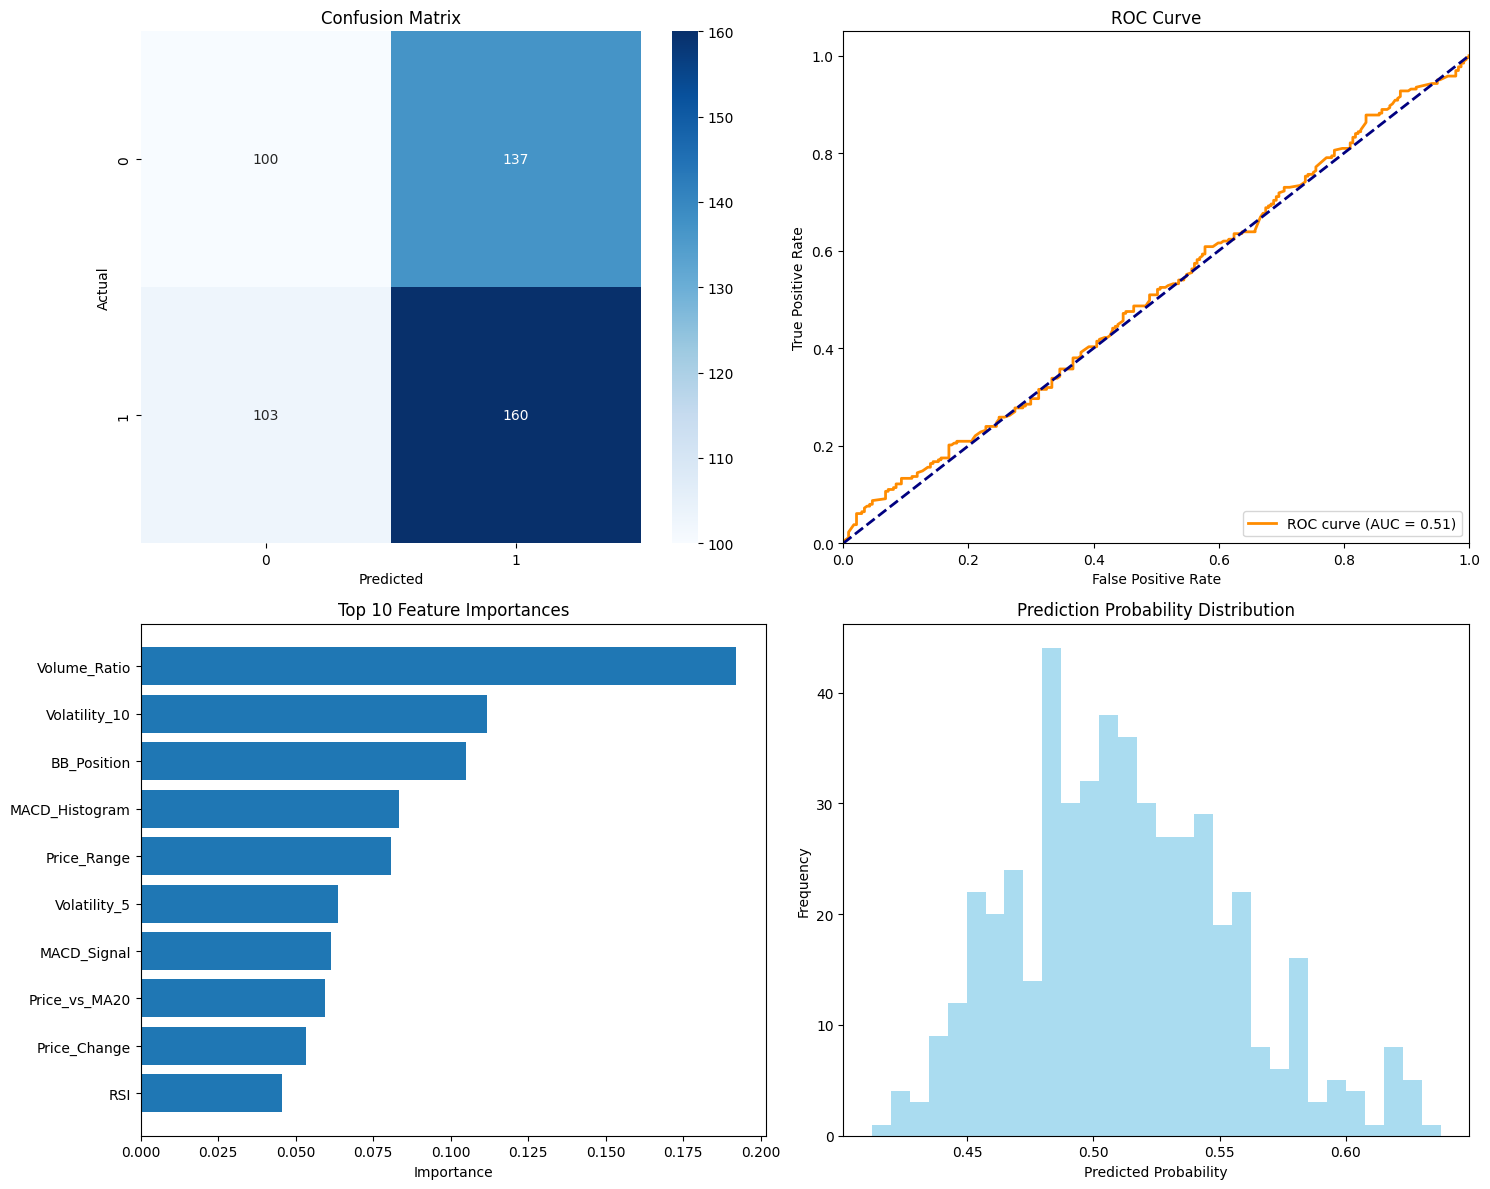

In [12]:
df = pd.read_csv("D:\ML PROJECTS\AML lab\dataset\HistoricalQuotes.csv")
analyzer = StockAdaBoostAnalyzer()
results = analyzer.run_complete_analysis(df)

In [19]:
import pandas as pd
import numpy as np
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

class StockAdaBoostAnalyzer:
    def __init__(self):
        self.scaler = StandardScaler()
        self.model = None
        self.feature_names = None
        
    def load_and_preprocess_data(self, df):
        """
        Load and preprocess the stock data
        """
        # Create a copy of the dataframe
        data = df.copy()
        
        # Convert Date to datetime if it's not already
        if data['Date'].dtype == 'object':
            data['Date'] = pd.to_datetime(data['Date'])
        
        # Clean price columns (remove $ and convert to float)
        price_columns = [' Close/Last', ' Open', ' High', ' Low']
        for col in price_columns:
            if col in data.columns:
                if data[col].dtype == 'object':
                    data[col] = data[col].str.replace('$', '').astype(float)
        
        # Sort by date
        data = data.sort_values('Date').reset_index(drop=True)
        
        return data
    
    def engineer_features(self, data):
        """
        Create technical indicators and features for AdaBoost
        """
        df = data.copy()
        
        # Basic price features
        df['Price_Range'] = df[' High'] - df[' Low']
        df['Price_Change'] = df[' Close/Last'] - df[' Open']
        df['Price_Change_Pct'] = (df[' Close/Last'] - df[' Open']) / df[' Open'] * 100
        
        # Moving averages
        df['MA_5'] = df[' Close/Last'].rolling(window=5).mean()
        df['MA_10'] = df[' Close/Last'].rolling(window=10).mean()
        df['MA_20'] = df[' Close/Last'].rolling(window=20).mean()
        
        # Price relative to moving averages
        df['Price_vs_MA5'] = df[' Close/Last'] / df['MA_5']
        df['Price_vs_MA10'] = df[' Close/Last'] / df['MA_10']
        df['Price_vs_MA20'] = df[' Close/Last'] / df['MA_20']
        
        # Volatility measures
        df['Volatility_5'] = df[' Close/Last'].rolling(window=5).std()
        df['Volatility_10'] = df[' Close/Last'].rolling(window=10).std()
        
        # Volume features
        df['Volume_MA_5'] = df[' Volume'].rolling(window=5).mean()
        df['Volume_Ratio'] = df[' Volume'] / df['Volume_MA_5']
        
        # RSI (Relative Strength Index)
        delta = df[' Close/Last'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / loss
        df['RSI'] = 100 - (100 / (1 + rs))
        
        # MACD
        exp1 = df[' Close/Last'].ewm(span=12).mean()
        exp2 = df[' Close/Last'].ewm(span=26).mean()
        df['MACD'] = exp1 - exp2
        df['MACD_Signal'] = df['MACD'].ewm(span=9).mean()
        df['MACD_Histogram'] = df['MACD'] - df['MACD_Signal']
        
        # Bollinger Bands
        df['BB_Middle'] = df[' Close/Last'].rolling(window=20).mean()
        bb_std = df[' Close/Last'].rolling(window=20).std()
        df['BB_Upper'] = df['BB_Middle'] + (bb_std * 2)
        df['BB_Lower'] = df['BB_Middle'] - (bb_std * 2)
        df['BB_Position'] = (df[' Close/Last'] - df['BB_Lower']) / (df['BB_Upper'] - df['BB_Lower'])
        
        # Add more sophisticated features
        df['Price_Momentum_3'] = df[' Close/Last'] / df[' Close/Last'].shift(3)
        df['Price_Momentum_5'] = df[' Close/Last'] / df[' Close/Last'].shift(5)
        df['Price_Momentum_10'] = df[' Close/Last'] / df[' Close/Last'].shift(10)
        
        # Volume-price indicators
        df['Volume_Price_Trend'] = df[' Volume'] * df['Price_Change_Pct']
        df['Price_Volume_Ratio'] = df[' Close/Last'] / df[' Volume']
        
        # Advanced volatility measures
        df['Volatility_Ratio'] = df['Volatility_5'] / df['Volatility_10']
        df['Price_Range_Ratio'] = df['Price_Range'] / df[' Close/Last']
        
        # Trend indicators
        df['Trend_Strength'] = np.where(
            (df[' Close/Last'] > df['MA_5']) & (df['MA_5'] > df['MA_10']) & (df['MA_10'] > df['MA_20']),
            1,  # Strong uptrend
            np.where(
                (df[' Close/Last'] < df['MA_5']) & (df['MA_5'] < df['MA_10']) & (df['MA_10'] < df['MA_20']),
                -1,  # Strong downtrend
                0   # Sideways/weak trend
            )
        )
        
        # Stochastic oscillator
        low_14 = df[' Low'].rolling(window=14).min()
        high_14 = df[' High'].rolling(window=14).max()
        df['Stochastic_K'] = 100 * ((df[' Close/Last'] - low_14) / (high_14 - low_14))
        df['Stochastic_D'] = df['Stochastic_K'].rolling(window=3).mean()
        
        # Williams %R
        df['Williams_R'] = -100 * ((high_14 - df[' Close/Last']) / (high_14 - low_14))
        
        # Commodity Channel Index (CCI)
        typical_price = (df[' High'] + df[' Low'] + df[' Close/Last']) / 3
        sma_tp = typical_price.rolling(window=20).mean()
        mad = typical_price.rolling(window=20).apply(lambda x: np.mean(np.abs(x - x.mean())))
        df['CCI'] = (typical_price - sma_tp) / (0.015 * mad)
        
        # Average True Range (ATR)
        high_low = df[' High'] - df[' Low']
        high_close = np.abs(df[' High'] - df[' Close/Last'].shift())
        low_close = np.abs(df[' Low'] - df[' Close/Last'].shift())
        true_range = np.maximum(high_low, np.maximum(high_close, low_close))
        df['ATR'] = true_range.rolling(window=14).mean()
        
        # Money Flow Index (MFI)
        typical_price = (df[' High'] + df[' Low'] + df[' Close/Last']) / 3
        money_flow = typical_price * df[' Volume']
        positive_flow = money_flow.where(typical_price > typical_price.shift(1), 0)
        negative_flow = money_flow.where(typical_price < typical_price.shift(1), 0)
        positive_mf = positive_flow.rolling(window=14).sum()
        negative_mf = negative_flow.rolling(window=14).sum()
        mf_ratio = positive_mf / negative_mf
        df['MFI'] = 100 - (100 / (1 + mf_ratio))
        
        # Rate of Change (ROC)
        df['ROC_5'] = ((df[' Close/Last'] - df[' Close/Last'].shift(5)) / df[' Close/Last'].shift(5)) * 100
        df['ROC_10'] = ((df[' Close/Last'] - df[' Close/Last'].shift(10)) / df[' Close/Last'].shift(10)) * 100
        
        # Create target variable (next day price movement)
        df['Next_Close'] = df[' Close/Last'].shift(-1)
        df['Target'] = (df['Next_Close'] > df[' Close/Last']).astype(int)
        
        # Select features for modeling (expanded feature set)
        feature_columns = [
            # Basic price features
            'Price_Range', 'Price_Change', 'Price_Change_Pct',
            'Price_vs_MA5', 'Price_vs_MA10', 'Price_vs_MA20',
            
            # Volatility
            'Volatility_5', 'Volatility_10', 'Volatility_Ratio',
            
            # Volume
            'Volume_Ratio', 'Volume_Price_Trend', 'Price_Volume_Ratio',
            
            # Momentum
            'Price_Momentum_3', 'Price_Momentum_5', 'Price_Momentum_10',
            
            # Technical indicators
            'RSI', 'MACD', 'MACD_Signal', 'MACD_Histogram',
            'BB_Position', 'Stochastic_K', 'Stochastic_D',
            'Williams_R', 'CCI', 'ATR', 'MFI',
            'ROC_5', 'ROC_10',
            
            # Trend
            'Trend_Strength', 'Price_Range_Ratio'
        ]
        
        # Remove rows with NaN values
        df = df.dropna()
        
        return df, feature_columns
    
    def train_adaboost(self, X, y, test_size=0.2, random_state=42):
        """
        Train AdaBoost classifier with extensive hyperparameter tuning
        """
        from sklearn.model_selection import RandomizedSearchCV
        
        # Split the data with stratification for time series
        # Use time-based split to avoid data leakage
        split_idx = int(len(X) * (1 - test_size))
        X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
        y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
        
        print(f"Training set size: {len(X_train)}")
        print(f"Test set size: {len(X_test)}")
        print(f"Training target distribution: {y_train.value_counts(normalize=True).to_dict()}")
        
        # Scale the features
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)
        
        # Hyperparameter tuning with expanded parameter grid
        print("Performing extensive hyperparameter tuning...")
        print("This may take several minutes due to expanded parameter space...")
        
        param_grid = {
            'n_estimators': [50, 100, 200, 300, 500, 750, 1000],
            'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 1.2, 1.5, 2.0],
            'estimator__max_depth': [1, 2, 3, 4, 5, 6, 7],
            'estimator__min_samples_split': [2, 5, 10, 15, 20],
            'estimator__min_samples_leaf': [1, 2, 4, 6, 8, 10],
            'estimator__max_features': ['sqrt', 'log2', None, 0.3, 0.5, 0.7, 0.9],
            'algorithm': ['SAMME', 'SAMME.R']
        }
        
        # Use different base estimators
        base_estimator = DecisionTreeClassifier(
            random_state=random_state,
            criterion='gini',  # Also try 'entropy'
            splitter='best'    # Also try 'random'
        )
        
        ada_boost = AdaBoostClassifier(
            estimator=base_estimator,  # Changed from base_estimator
            random_state=random_state
        )
        
        # Use RandomizedSearchCV for efficiency with large parameter space
        from sklearn.model_selection import RandomizedSearchCV
        
        # First do randomized search to narrow down parameter space
        print("Phase 1: Randomized search with 100 iterations...")
        randomized_search = RandomizedSearchCV(
            ada_boost, 
            param_grid, 
            n_iter=100,  # Try 100 random combinations
            cv=5, 
            scoring='roc_auc',  # Use AUC as primary metric
            n_jobs=-1,
            random_state=random_state,
            verbose=1
        )
        randomized_search.fit(X_train_scaled, y_train)
        
        print(f"Best parameters from randomized search: {randomized_search.best_params_}")
        print(f"Best randomized search score: {randomized_search.best_score_:.4f}")
        
        # Phase 2: Fine-tune around best parameters
        print("\nPhase 2: Fine-tuning around best parameters...")
        best_params = randomized_search.best_params_
        
        # Create refined grid around best parameters
        refined_param_grid = {}
        
        # Refine n_estimators
        best_n_est = best_params['n_estimators']
        refined_param_grid['n_estimators'] = [
            max(50, best_n_est - 100),
            best_n_est,
            best_n_est + 100,
            min(1200, best_n_est + 200)
        ]
        
        # Refine learning_rate
        best_lr = best_params['learning_rate']
        lr_range = [best_lr * 0.5, best_lr * 0.8, best_lr, best_lr * 1.2, best_lr * 1.5]
        refined_param_grid['learning_rate'] = [max(0.01, min(3.0, lr)) for lr in lr_range]
        
        # Keep best algorithm and base estimator params
        for key in ['algorithm', 'estimator__max_depth', 'estimator__min_samples_split',
                    'estimator__min_samples_leaf', 'estimator__max_features']:
            if key in best_params:
                # Add some variation around best values
                if key == 'estimator__max_depth':
                    depth = best_params[key]
                    refined_param_grid[key] = [max(1, depth-1), depth, min(10, depth+1)]
                elif key == 'estimator__min_samples_split':
                    split = best_params[key]
                    refined_param_grid[key] = [max(2, split-2), split, split+3]
                elif key == 'estimator__min_samples_leaf':
                    leaf = best_params[key]
                    refined_param_grid[key] = [max(1, leaf-1), leaf, leaf+2]
                else:
                    refined_param_grid[key] = [best_params[key]]
        
        # Final grid search with refined parameters
        final_grid_search = GridSearchCV(
            ada_boost, 
            refined_param_grid, 
            cv=7,  # More folds for better estimation
            scoring='roc_auc',
            n_jobs=-1,
            verbose=1
        )
        final_grid_search.fit(X_train_scaled, y_train)
        
        grid_search = final_grid_search  # Use final results
        
        # Alternative: Try different base estimators if AdaBoost still performs poorly
        print("\nTesting alternative configurations...")
        
        # Test with different base estimators
        from sklearn.linear_model import LogisticRegression
        from sklearn.naive_bayes import GaussianNB
        
        alternative_estimators = {
            'DecisionTree_Entropy': DecisionTreeClassifier(
                criterion='entropy', 
                random_state=random_state,
                **{k.replace('estimator__', ''): v for k, v in grid_search.best_params_.items() 
                   if k.startswith('estimator__')}
            ),
            'LogisticRegression': LogisticRegression(random_state=random_state, max_iter=1000),
            'GaussianNB': GaussianNB()
        }
        
        best_alternative_score = 0
        best_alternative_model = None
        best_alternative_name = ""
        
        for name, base_est in alternative_estimators.items():
            try:
                alt_ada = AdaBoostClassifier(
                    estimator=base_est,  # Changed from base_estimator
                    n_estimators=grid_search.best_params_['n_estimators'],
                    learning_rate=grid_search.best_params_['learning_rate'],
                    algorithm=grid_search.best_params_.get('algorithm', 'SAMME'),
                    random_state=random_state
                )
                
                # Quick cross-validation
                cv_scores = cross_val_score(alt_ada, X_train_scaled, y_train, cv=3, scoring='roc_auc')
                avg_score = cv_scores.mean()
                print(f"{name}: CV AUC = {avg_score:.4f}")
                
                if avg_score > best_alternative_score:
                    best_alternative_score = avg_score
                    best_alternative_model = alt_ada
                    best_alternative_name = name
                    
            except Exception as e:
                print(f"Failed to test {name}: {str(e)}")
        
        # Use best alternative if it's better than original
        if best_alternative_score > grid_search.best_score_:
            print(f"\nUsing alternative estimator: {best_alternative_name}")
            print(f"Alternative score: {best_alternative_score:.4f} vs Original: {grid_search.best_score_:.4f}")
            self.model = best_alternative_model
            self.model.fit(X_train_scaled, y_train)
        else:
            # Train the best model from grid search
            self.model = grid_search.best_estimator_
        # Also try class balancing techniques
        print("\nTesting with class balancing...")
        from sklearn.utils.class_weight import compute_class_weight
        
        # Calculate class weights
        classes = np.unique(y_train)
        class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
        class_weight_dict = dict(zip(classes, class_weights))
        print(f"Class weights: {class_weight_dict}")
        
        # Try with balanced class weights (if base estimator supports it)
        try:
            balanced_base = DecisionTreeClassifier(
                random_state=random_state,
                class_weight='balanced',
                **{k.replace('estimator__', ''): v for k, v in grid_search.best_params_.items() 
                   if k.startswith('estimator__')}
            )
            
            balanced_ada = AdaBoostClassifier(
                estimator=balanced_base,  # Changed from base_estimator
                n_estimators=grid_search.best_params_['n_estimators'],
                learning_rate=grid_search.best_params_['learning_rate'],
                algorithm=grid_search.best_params_.get('algorithm', 'SAMME'),
                random_state=random_state
            )
            
            balanced_cv_scores = cross_val_score(balanced_ada, X_train_scaled, y_train, cv=3, scoring='roc_auc')
            balanced_score = balanced_cv_scores.mean()
            print(f"Balanced classes: CV AUC = {balanced_score:.4f}")
            
            if balanced_score > grid_search.best_score_ and (best_alternative_model is None or balanced_score > best_alternative_score):
                print("Using balanced class weights model")
                self.model = balanced_ada
                self.model.fit(X_train_scaled, y_train)
        except Exception as e:
            print(f"Class balancing failed: {str(e)}")
        
        print(f"Final best parameters: {grid_search.best_params_}")
        print(f"Final best cross-validation score: {grid_search.best_score_:.4f}")
        
        # Make predictions
        y_pred = self.model.predict(X_test_scaled)
        y_pred_proba = self.model.predict_proba(X_test_scaled)[:, 1]
        
        # Store results
        self.results = {
            'X_test': X_test_scaled,
            'y_test': y_test,
            'y_pred': y_pred,
            'y_pred_proba': y_pred_proba,
            'best_params': grid_search.best_params_,
            'feature_names': self.feature_names
        }
        
        return self.results
    
    def evaluate_model(self):
        """
        Evaluate the AdaBoost model performance
        """
        if self.results is None:
            print("Model not trained yet!")
            return
        
        y_test = self.results['y_test']
        y_pred = self.results['y_pred']
        y_pred_proba = self.results['y_pred_proba']
        
        # Basic metrics
        accuracy = accuracy_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_pred_proba)
        
        print("="*50)
        print("ADABOOST MODEL EVALUATION")
        print("="*50)
        print(f"Accuracy: {accuracy:.4f}")
        print(f"ROC AUC Score: {roc_auc:.4f}")
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        
        # Feature importance
        if hasattr(self.model, 'feature_importances_'):
            feature_importance = pd.DataFrame({
                'feature': self.feature_names,
                'importance': self.model.feature_importances_
            }).sort_values('importance', ascending=False)
            
            print("\nTop 10 Feature Importances:")
            print(feature_importance.head(10))
        else:
            # Handle case where model doesn't have feature_importances_ (some base estimators)
            print("\nFeature importance not available for this model type")
            feature_importance = pd.DataFrame({'feature': self.feature_names, 'importance': [0]*len(self.feature_names)})
        
        return {
            'accuracy': accuracy,
            'roc_auc': roc_auc,
            'feature_importance': feature_importance
        }
    
    def plot_results(self):
        """
        Create visualizations for the AdaBoost results
        """
        if self.results is None:
            print("Model not trained yet!")
            return
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        
        # 1. Confusion Matrix
        cm = confusion_matrix(self.results['y_test'], self.results['y_pred'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0])
        axes[0,0].set_title('Confusion Matrix')
        axes[0,0].set_xlabel('Predicted')
        axes[0,0].set_ylabel('Actual')
        
        # 2. ROC Curve
        fpr, tpr, _ = roc_curve(self.results['y_test'], self.results['y_pred_proba'])
        roc_auc = roc_auc_score(self.results['y_test'], self.results['y_pred_proba'])
        axes[0,1].plot(fpr, tpr, color='darkorange', lw=2, 
                       label=f'ROC curve (AUC = {roc_auc:.2f})')
        axes[0,1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        axes[0,1].set_xlim([0.0, 1.0])
        axes[0,1].set_ylim([0.0, 1.05])
        axes[0,1].set_xlabel('False Positive Rate')
        axes[0,1].set_ylabel('True Positive Rate')
        axes[0,1].set_title('ROC Curve')
        axes[0,1].legend(loc="lower right")
        
        # 3. Feature Importance
        if hasattr(self.model, 'feature_importances_'):
            feature_importance = pd.DataFrame({
                'feature': self.feature_names,
                'importance': self.model.feature_importances_
            }).sort_values('importance', ascending=True).tail(10)
            
            axes[1,0].barh(range(len(feature_importance)), feature_importance['importance'])
            axes[1,0].set_yticks(range(len(feature_importance)))
            axes[1,0].set_yticklabels(feature_importance['feature'])
            axes[1,0].set_title('Top 10 Feature Importances')
            axes[1,0].set_xlabel('Importance')
        
        # 4. Prediction Distribution
        axes[1,1].hist(self.results['y_pred_proba'], bins=30, alpha=0.7, color='skyblue')
        axes[1,1].set_title('Prediction Probability Distribution')
        axes[1,1].set_xlabel('Predicted Probability')
        axes[1,1].set_ylabel('Frequency')
        
        plt.tight_layout()
        plt.show()
    
    def run_complete_analysis(self, df):
        """
        Run the complete AdaBoost analysis pipeline
        """
        print("Starting AdaBoost Analysis...")
        print("="*50)
        
        # 1. Preprocess data
        print("1. Preprocessing data...")
        data = self.load_and_preprocess_data(df)
        
        # 2. Engineer features
        print("2. Engineering features...")
        data_with_features, feature_columns = self.engineer_features(data)
        self.feature_names = feature_columns
        
        print(f"Created {len(feature_columns)} features")
        print(f"Dataset shape after preprocessing: {data_with_features.shape}")
        
        # 3. Prepare features and target
        X = data_with_features[feature_columns]
        y = data_with_features['Target']
        
        print(f"Target distribution:")
        print(y.value_counts(normalize=True))
        
        # 4. Train AdaBoost model
        print("\n3. Training AdaBoost model...")
        self.train_adaboost(X, y)
        
        # 5. Evaluate model
        print("\n4. Evaluating model...")
        evaluation_results = self.evaluate_model()
        
        # 6. Plot results
        print("\n5. Creating visualizations...")
        self.plot_results()
        
        return evaluation_results

# Example usage:
# Assuming your dataframe is called 'df'
# analyzer = StockAdaBoostAnalyzer()
# results = analyzer.run_complete_analysis(df)

"""
USAGE INSTRUCTIONS:
1. Load your dataset into a pandas DataFrame
2. Create an instance of StockAdaBoostAnalyzer
3. Call run_complete_analysis(df) with your dataframe
4. The algorithm will automatically:
   - Clean and preprocess the data
   - Create technical indicators as features
   - Train an AdaBoost classifier with hyperparameter tuning
   - Evaluate the model performance
   - Generate visualizations

Example:
df = pd.read_csv('your_stock_data.csv')
analyzer = StockAdaBoostAnalyzer()
results = analyzer.run_complete_analysis(df)
"""

"\nUSAGE INSTRUCTIONS:\n1. Load your dataset into a pandas DataFrame\n2. Create an instance of StockAdaBoostAnalyzer\n3. Call run_complete_analysis(df) with your dataframe\n4. The algorithm will automatically:\n   - Clean and preprocess the data\n   - Create technical indicators as features\n   - Train an AdaBoost classifier with hyperparameter tuning\n   - Evaluate the model performance\n   - Generate visualizations\n\nExample:\ndf = pd.read_csv('your_stock_data.csv')\nanalyzer = StockAdaBoostAnalyzer()\nresults = analyzer.run_complete_analysis(df)\n"

Starting AdaBoost Analysis...
1. Preprocessing data...
2. Engineering features...
Created 30 features
Dataset shape after preprocessing: (2498, 45)
Target distribution:
Target
1    0.526421
0    0.473579
Name: proportion, dtype: float64

3. Training AdaBoost model...
Training set size: 1998
Test set size: 500
Training target distribution: {1: 0.5215215215215215, 0: 0.47847847847847846}
Performing extensive hyperparameter tuning...
This may take several minutes due to expanded parameter space...
Phase 1: Randomized search with 100 iterations...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best parameters from randomized search: {'n_estimators': 50, 'learning_rate': 0.01, 'estimator__min_samples_split': 15, 'estimator__min_samples_leaf': 1, 'estimator__max_features': 'log2', 'estimator__max_depth': 5, 'algorithm': 'SAMME'}
Best randomized search score: 0.5275

Phase 2: Fine-tuning around best parameters...
Fitting 7 folds for each of 540 candidates, totalling 3780 fits


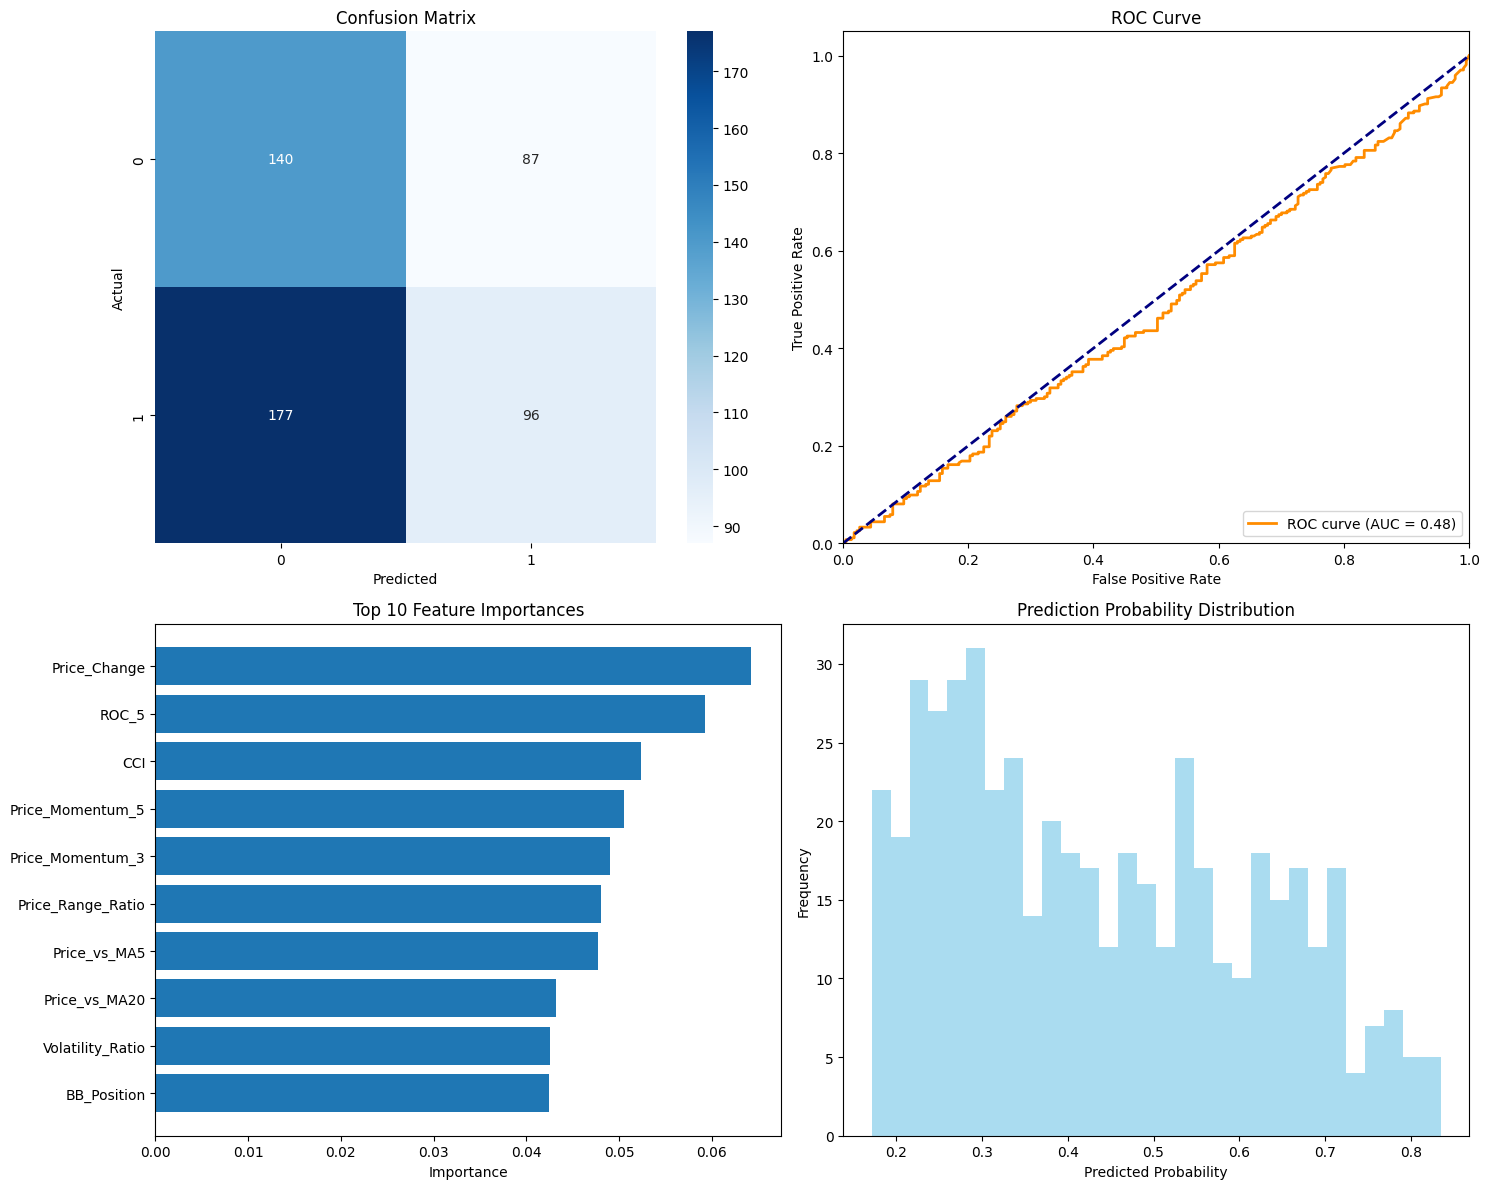

In [20]:
df = pd.read_csv("D:\ML PROJECTS\AML lab\dataset\HistoricalQuotes.csv")
analyzer = StockAdaBoostAnalyzer()
results = analyzer.run_complete_analysis(df)